<a href="https://colab.research.google.com/github/ajgquional/classical-ml-experiments/blob/main/AI221/MEX11/ai221_mex11_automl_quional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI 221 Assignment 12: AutoML and XAI

<b>Description:</b> This notebook once again demonstrates classification on the students' dropout and academic success, this time particularly demonstrating AutoML and Explainable AI. Dataset used is the Students' Dropout and Academic Success Dataset that can be found on https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success.
<br>
<br>
<b>Author:</b> Adrian Josele G. Quional
<br>
<b>Submitted to:</b> Dr. Jon Dewitt E. Dalisay
<br>
<b>Semester/Year:</b> 2nd Semester/2024-2025
<br>
<br>
(Notebook originally created in Google Colab)

Here, `PyCaret` is used for AutoML instead of `auto-sklearn` because there is a problem on using the latter without resorting to using Docker. Apparently, to date, `auto-sklearn` works on older versions of Python, not Python 3.11 which is the current Python version in Google Colab.

The cells below installs external libraries not included, by default, in Google Colab. After installing, session must be restarted.

In [ ]:
# installing external libraries
!pip install pycaret optuna ucimlrepo # AutoML, Bayesian optimization of hyperparameters, and data repository

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.7/169.7 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 15.5 MB/s eta 0:00:00
   ━

In [ ]:
# imports

# UCI ML repo
from ucimlrepo import fetch_ucirepo

# for plotting and general dataset manipulation
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# scikit-learn for data processing and evaluation
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

# other libraries
from pycaret.classification import * # PyCaret classification
import optuna # for Bayesian optimization
import time # for inference timing

# to suppress warnings
import warnings
warnings.filterwarnings('ignore')

## Data fetching and processing

This section fetches the data and processes. Since the dataset used is the same as before, no preliminary checks are conducted because it is already assured that the data is clean. Also, extensive EDA is not conducted as it has been done already in the previous assignments.

In [ ]:
# fetching the dataset
student = fetch_ucirepo(id=697) # alternatively: fetch_ucirepo(name="Predict Students' Dropout and Academic Success")
student_df = student.data.original

# checking the original dataset
student_df.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
# defining feature types

continuous_cols = [
    "Previous qualification (grade)", "Admission grade", "Age at enrollment",
    "Curricular units 1st sem (credited)", "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)", "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)", "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)", "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)", "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate", "Inflation rate", "GDP"
]

ordinal_cols = [
    "Application order", "Previous qualification",
    "Mother's qualification", "Father's qualification"
]

categorical_cols = [
    "Marital Status", "Application mode", "Course", "Nacionality",
    "Mother's occupation", "Father's occupation"
]

binary_cols = [
    "Daytime/evening attendance", "Displaced", "Educational special needs",
    "Debtor", "Tuition fees up to date", "Gender", "Scholarship holder", "International"
]

target_col = "Target"

# separating the columns

# features
X_continuous = student_df[continuous_cols]
X_ordinal = student_df[ordinal_cols]
X_categorical = student_df[categorical_cols]
X_binary = student_df[binary_cols]

# target
y = student_df[target_col]

# preprocessing

# standardizing continuous features
scaler_continuous = StandardScaler()
X_continuous_scaled = pd.DataFrame(
    scaler_continuous.fit_transform(X_continuous),
    columns=continuous_cols
)

# standardizing ordinal features
scaler_ordinal = StandardScaler()
X_ordinal_scaled = pd.DataFrame(
    scaler_ordinal.fit_transform(X_ordinal),
    columns=ordinal_cols
)

# one-hot encoding categorical features
encoder_categorical = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_categorical_encoded = pd.DataFrame(
    encoder_categorical.fit_transform(X_categorical),
    columns=encoder_categorical.get_feature_names_out(categorical_cols)
)

# binary features left as is
X_binary_copy = X_binary.copy()

# combining all transformed features
X_full = pd.concat(
    [X_continuous_scaled, X_ordinal_scaled, X_categorical_encoded, X_binary_copy],
    axis=1
)

print(f"Final shape of the feature matrix: {X_full.shape}")

# encoding the target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_labels = label_encoder.classes_

# checking the class labels
print(f"Class labels: {class_labels}")

Final shape of the feature matrix: (4424, 170)
Class labels: ['Dropout' 'Enrolled' 'Graduate']


Transformed dataset has 170 columns (primarily due to one-hot encoding).

In [ ]:
# splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_encoded,
    test_size=0.2,  # or whatever test size you want
    random_state=42,  # for reproducibility
    stratify=y_encoded  # for having balanced classes in train/test
)

print(f"Train set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Train target set size: {y_train.shape}")
print(f"Test target set size: {y_test.shape}")

Train set size: (3539, 170)
Test set size: (885, 170)
Train target set size: (3539,)
Test target set size: (885,)


## PyCaret best model selection

Here, we use `PyCaret` to get the best model from a wide selection of classical machine learning methods. Specifically, the methods tested here are:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Naive Bayes
4. Decision Tree Classifier
5. Random Forest Classifier
6. Gradient Boosting Classifier
7. LightGBM Classifier
8. XGBoost Classifier
9. CatBoost Classifier
10. Support Vector Classifier (SVC)

In [ ]:
# for PyCaret

# for training (PyCaret needs to have a combined DataFrame)
train_df = X_train.copy()
train_df['Target'] = y_train  # adding the target back

# for testing
test_df = X_test.copy()
test_df['Target'] = y_test  # adding the target back

In [ ]:
# PyCaret setup:
clf_setup = setup(
    data=train_df,
    target='Target',
    test_data=test_df,  # setting aside test set
    train_size=0.8,     # already have split, but just specify
    session_id=42,      # for reproducibility
    normalize=False,    # already have scaled continuous and ordinal features
    transformation=False,
    categorical_features=None,  # already have one-hot encoded categorical features
    ignore_features=None,
    verbose=True
)

# finding the best model (it will take a while to find the best model)
best_model = compare_models()

,Description,Value
0,Session id,42
1,Target,Target
2,Target type,Multiclass
3,Original data shape,"(4424, 171)"
4,Transformed data shape,"(4424, 171)"
5,Transformed train set shape,"(3539, 171)"
6,Transformed test set shape,"(885, 171)"
7,Numeric features,170
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7838,0.9089,0.7838,0.7744,0.7753,0.6389,0.6427,1.2030
lr,Logistic Regression,0.7830,0.0000,0.7830,0.7704,0.7699,0.6340,0.6405,0.9880
gbc,Gradient Boosting Classifier,0.7787,0.0000,0.7787,0.7685,0.7683,0.6283,0.6337,3.3990
xgboost,Extreme Gradient Boosting,0.7782,0.9070,0.7782,0.7693,0.7700,0.6299,0.6336,0.7840
et,Extra Trees Classifier,0.7725,0.9001,0.7725,0.7601,0.7514,0.6092,0.6231,0.8230
rf,Random Forest Classifier,0.7677,0.9015,0.7677,0.7518,0.7468,0.6026,0.6141,0.7630
ridge,Ridge Classifier,0.7638,0.0000,0.7638,0.7459,0.7331,0.5891,0.6094,0.0710
lda,Linear Discriminant Analysis,0.7624,0.0000,0.7624,0.7553,0.7514,0.5981,0.6067,0.1060
svm,SVM - Linear Kernel,0.7587,0.0000,0.7587,0.7450,0.7456,0.5959,0.6014,0.2810
ada,Ada Boost Classifier,0.7581,0.0000,0.7581,0.7482,0.7502,0.5972,0.6003,0.3420


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
# displaying the best model's hyperparameters
print("Best model's hyperparameters:")
for param, value in best_model.get_params().items():
    print(f"\t{param}: {value}")

Best model's hyperparameters:
	boosting_type: gbdt
	class_weight: None
	colsample_bytree: 1.0
	importance_type: split
	learning_rate: 0.1
	max_depth: -1
	min_child_samples: 20
	min_child_weight: 0.001
	min_split_gain: 0.0
	n_estimators: 100
	n_jobs: -1
	num_leaves: 31
	objective: None
	random_state: 42
	reg_alpha: 0.0
	reg_lambda: 0.0
	subsample: 1.0
	subsample_for_bin: 200000
	subsample_freq: 0


In [ ]:
# getting the best model and tuning it to see if it can be further improved (the best model from PyCaret is LightGBM, if session_id is set to 42)
pycaret_final_model = tune_model(create_model('lightgbm'))

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7740,0.9005,0.7740,0.7652,0.7662,0.6219,0.6259
1,0.7655,0.8994,0.7655,0.7584,0.7593,0.6092,0.6122
2,0.7797,0.9063,0.7797,0.7670,0.7702,0.6315,0.6348
3,0.8023,0.9183,0.8023,0.7903,0.7888,0.6665,0.6724
4,0.7768,0.9142,0.7768,0.7640,0.7670,0.6268,0.6304
5,0.7910,0.9215,0.7910,0.7782,0.7818,0.6515,0.6544
6,0.8107,0.9211,0.8107,0.8026,0.8038,0.6847,0.6876
7,0.7655,0.9000,0.7655,0.7555,0.7573,0.6089,0.6124
8,0.8136,0.9093,0.8136,0.8062,0.8028,0.6860,0.6929


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7571,0.8949,0.7571,0.7442,0.7470,0.5926,0.5968
1,0.7655,0.8861,0.7655,0.7562,0.7537,0.6027,0.6098
2,0.7684,0.9155,0.7684,0.7517,0.7557,0.6105,0.6151
3,0.7825,0.8992,0.7825,0.7660,0.7659,0.6311,0.6385
4,0.7627,0.9081,0.7627,0.7450,0.7496,0.6018,0.6060
5,0.8023,0.9227,0.8023,0.7941,0.7955,0.6707,0.6737
6,0.8079,0.9190,0.8079,0.7984,0.7984,0.6778,0.6825
7,0.7712,0.8984,0.7712,0.7612,0.7622,0.6172,0.6214
8,0.8051,0.9083,0.8051,0.7953,0.7933,0.6717,0.6784


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


## Optuna/Bayesian optimization of own model (informed by PyCaret)

Here, we create our own LightGBM model (as informed by `PyCaret`), Bayesian-optimized via `Optuna`.

In [ ]:
# importing lightgbm
import lightgbm as lgb

# defining the Optuna objective function for hyperparameter optimization
def objective(trial):
    param = {
        'objective': 'multiclass',
        'num_class': 3,  # number of classes in your target
        'boosting_type': 'gbdt',
        'metric': 'multi_logloss',
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.1),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
    }

    # defining LightGBM model with verbose set to -1 to suppress warnings
    model = lgb.LGBMClassifier(**param, verbose=-1, random_state=42)
    model.fit(X_train, y_train)  # fitting on training data
    y_pred = model.predict(X_test)  # predicting on test data
    score = classification_report(y_test, y_pred, output_dict=True)['accuracy']  # maximizing accuracy
    return score

# running Optuna for hyperparameter optimization
optuna_study = optuna.create_study(direction='maximize')
optuna_study.optimize(objective, n_trials=5) # increase number of trials if needed

# getting the best hyperparameters from Optuna
best_params = optuna_study.best_params
print("Best parameters from Optuna:")
for param, value in best_params.items():
    print(f"\t{param}: {value}")

Best parameters from Optuna:
	num_leaves: 185
	max_depth: 7
	learning_rate: 0.03171897897710312
	n_estimators: 160


In [ ]:
# training the Optuna-tuned LightGBM model
optuna_lgbm_model = lgb.LGBMClassifier(**best_params)
optuna_lgbm_model.fit(X_train, y_train)

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.03171897897710312,
               max_depth=7, min_child_samples=20, min_child_weight=0.001,
               min_split_gain=0.0, n_estimators=160, n_jobs=None,
               num_leaves=185, objective=None, random_state=None, reg_alpha=0.0,
               reg_lambda=0.0, subsample=1.0, subsample_for_bin=200000,
               subsample_freq=0)

In [ ]:
# printing hyperparameters of Optuna-tuned LightGBM, for easy comparison to the PyCaret model
print("Hyperparameters of Optuna-tuned LightGBM:")
for param, value in optuna_lgbm_model.get_params().items():
    print(f"\t{param}: {value}")

Hyperparameters of Optuna-tuned LightGBM:
	boosting_type: gbdt
	class_weight: None
	colsample_bytree: 1.0
	importance_type: split
	learning_rate: 0.03171897897710312
	max_depth: 7
	min_child_samples: 20
	min_child_weight: 0.001
	min_split_gain: 0.0
	n_estimators: 160
	n_jobs: None
	num_leaves: 185
	objective: None
	random_state: None
	reg_alpha: 0.0
	reg_lambda: 0.0
	subsample: 1.0
	subsample_for_bin: 200000
	subsample_freq: 0


## Evaluation (comparing PyCaret best model to Optuna-tuned model)

Here, we compare the two LightGBM models - one is a `PyCaret`-informed and another is `Optuna`-tuned. We compare them in terms of inference time, accuracy, and feature importance.

Inference time:

In [ ]:
# measuring inference time of PyCaret model
start_time = time.time()
pycaret_predictions = pycaret_final_model.predict(X_test)
pycaret_inference_time = time.time() - start_time
print(f"PyCaret Inference Time: {pycaret_inference_time:.4f} seconds")

# measuring inference time of Optuna-tuned LightGBM model
start_time = time.time()
optuna_predictions = optuna_lgbm_model.predict(X_test)
optuna_inference_time = time.time() - start_time
print(f"Optuna Inference Time: {optuna_inference_time:.4f} seconds")

PyCaret Inference Time: 0.0197 seconds
Optuna Inference Time: 0.0396 seconds


From the inference times, it seems that the `PyCaret` LightGBM is slightly faster compared to the `Optuna`-tuned LightGBM.

Classification report and confusion matrix:

Classification Report (PyCaret):
              precision    recall  f1-score   support

     Dropout       0.78      0.74      0.76       284
    Enrolled       0.52      0.42      0.46       159
    Graduate       0.82      0.90      0.86       442

    accuracy                           0.76       885
   macro avg       0.70      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



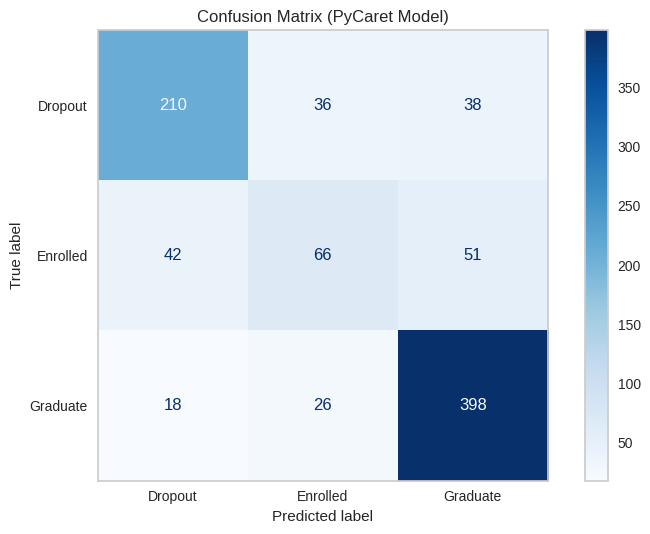

In [ ]:
# classification report and confusion matrix for PyCaret Model
print("Classification Report (PyCaret):")
print(classification_report(y_test, pycaret_predictions, target_names=class_labels))
ConfusionMatrixDisplay.from_predictions(y_test, pycaret_predictions, cmap="Blues", display_labels=class_labels)
plt.title("Confusion Matrix (PyCaret Model)")
plt.tight_layout()
plt.grid(False)
plt.show()

Classification Report (Optuna-Tuned LightGBM):
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       284
           1       0.54      0.42      0.48       159
           2       0.81      0.92      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.69      0.70       885
weighted avg       0.76      0.77      0.76       885



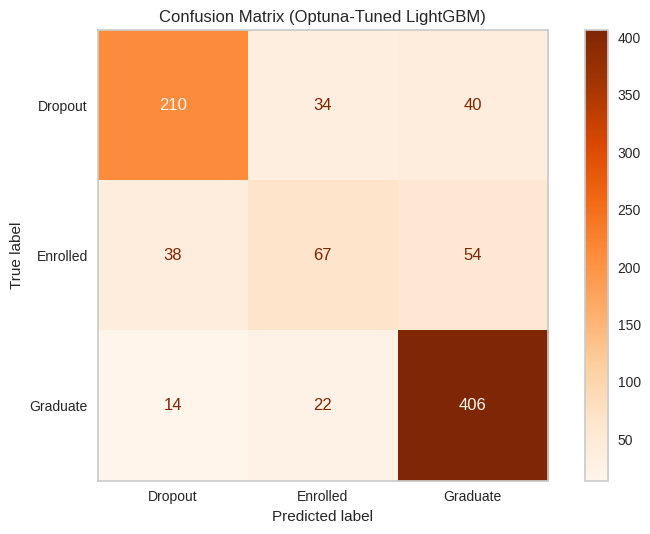

In [ ]:
# classification report and confusion matrix for Optuna-tuned LightGBM model
print("Classification Report (Optuna-Tuned LightGBM):")
print(classification_report(y_test, optuna_predictions))
ConfusionMatrixDisplay.from_predictions(y_test, optuna_predictions, cmap="Oranges", display_labels=class_labels)
plt.title("Confusion Matrix (Optuna-Tuned LightGBM)")
plt.tight_layout()
plt.grid(False)
plt.show()

Comparing the two models, the accuracies are close to each other, with the Bayesian-optimized LightGBM only slightly better (accuracy of 0.77 versus 0.76).

Feature importance (only looking at the top 20 since there are a lot of features from the processed dataset):

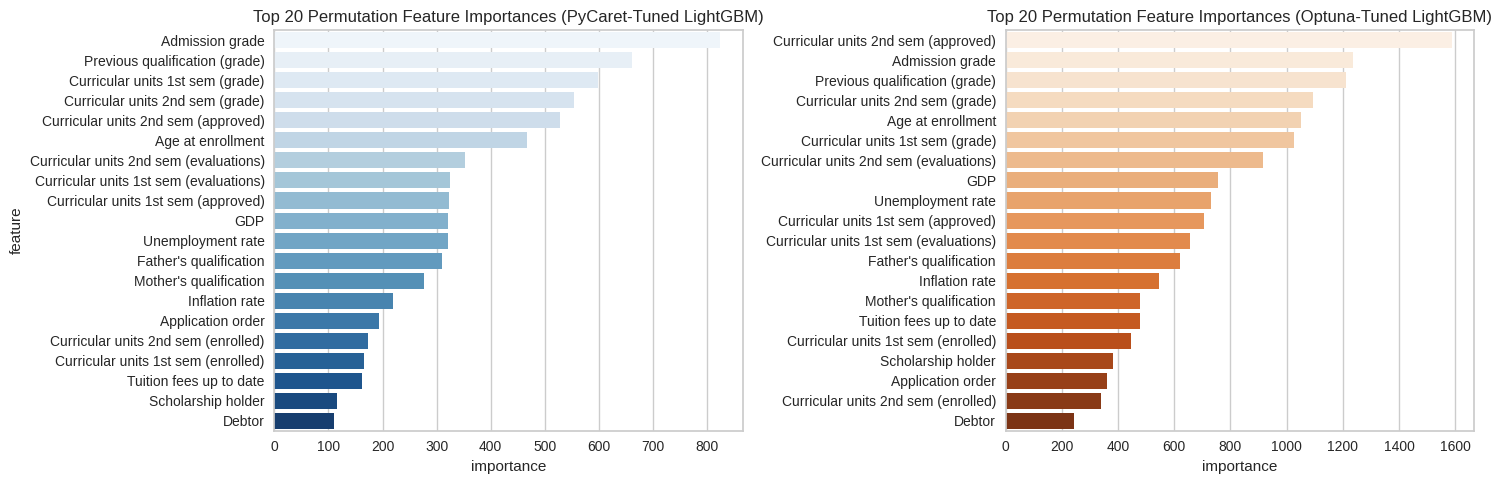

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# feature importance for PyCaret-tuned LightGBM model
pycaret_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': pycaret_final_model.feature_importances_
}).sort_values(by='importance', ascending=False).head(20) # getting only top 20 important features

sns.barplot(data=pycaret_importances, x='importance', y='feature', palette='Blues', ax=ax[0])
ax[0].set_title("Top 20 Permutation Feature Importances (PyCaret-Tuned LightGBM)")

# feature importance for Optuna-Tuned LightGBM Model
optuna_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': optuna_lgbm_model.feature_importances_
}).sort_values(by='importance', ascending=False).head(20) # getting only top 20 important features

sns.barplot(data=optuna_importances, x='importance', y='feature', palette='Oranges', ax=ax[1])
ax[1].set_title("Top 20 Permutation Feature Importances (Optuna-Tuned LightGBM)")
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

Looking at the feature importances, it can be seen that both models output almost the same top 20 important features, but the features are in a slightly different order. For the `PyCaret`-informed LightGBM, `Admission grade` is the most important feature while for the `Optuna`-tuned LightGBM, approved curricular units for 2nd sem proved to be the most important (with `Admission grade` following, which says that `Admission grade` is perhaps the best predictor for student status).

## Summary and Analysis

* Student status classification was once again conducted, this time to primarily demonstrate AutoML (via `PyCaret`) and Explainable AI (via feature importances).
* AutoML is performed using `PyCaret` rather than `auto-sklearn` (as was in the instruction) due to convenience. To date, `auto-sklearn` works with older versions of Python rather than the latest Python 3.11. In comparison, `PyCaret` works in the latest version and is easy to use. Nevetheless, whether using `auto-sklearn` or `PyCaret`, AutoML really proved easy model selection.
* By testing a variety of classical machine learning algorithms, `PyCaret` outputs LightGBM as the best model (however, this is dependent on the `session_id`, the "`random_state`", used). This is further tuned, but it has been found out that the best model is the original one obtained. The following are the hyperparameters obtained by the `PyCaret` LightGBM model:

```
    boosting_type: gbdt
	class_weight: None
	colsample_bytree: 1.0
	importance_type: split
	learning_rate: 0.1
	max_depth: -1
	min_child_samples: 20
	min_child_weight: 0.001
	min_split_gain: 0.0
	n_estimators: 100
	n_jobs: -1
	num_leaves: 31
	objective: None
	random_state: 42
	reg_alpha: 0.0
	reg_lambda: 0.0
	subsample: 1.0
	subsample_for_bin: 200000
	subsample_freq: 0
```

*  Using `Optuna`, a new LightGBM model is created, Bayesian-optimized. The following are the hyperparameters obtained:

```
	boosting_type: gbdt
	class_weight: None
	colsample_bytree: 1.0
	importance_type: split
	learning_rate: 0.03171897897710312
	max_depth: 7
	min_child_samples: 20
	min_child_weight: 0.001
	min_split_gain: 0.0
	n_estimators: 160
	n_jobs: None
	num_leaves: 185
	objective: None
	random_state: None
	reg_alpha: 0.0
	reg_lambda: 0.0
	subsample: 1.0
	subsample_for_bin: 200000
	subsample_freq: 0
```

* Primarily, what is tuned in `Optuna` are the `num_leaves`, `max_depth`, `learning_rate`, and `n_estimators`. Looking only at these hyperparameters from `PyCaret` to `Optuna`, and it seems that there are different values. For `num_leaves`, `PyCaret` obtained 31 while `Optuna` obtained 185. For `max_depth`, `PyCaret` has no limit (value of -1) while `Optuna` specified 7. For `learning_rate`, `PyCaret` obtained 0.1, while `Optuna` obtained about 0.03. Lastly, for `n_estimators`, `PyCaret` obtained 100 while `Optuna` obtained a slightly higher value - 160. Perhaps, the difference is due to the mismatch in the search spaces for the said hyperparameters. Also, the strategy of hyperparameter search is different for `PyCaret` - it used random search rather than Bayesian search.

* In terms of test accuracies, the two models are comparable, with the `Optuna`-tuned LightGBM being slightly better. This shows that, regardless of the difference in hyperparameters, both models achieved almost the same performance.

* In terms of inference times, the `PyCaret` LightGBM model is slightly faster.

* In terms of feature importance, `Admission grade` seemed to be a good predictor of student status, regardless of the LightGBM model used. In this regard, using feature importances is a small step to introduce explainability in the models. Personally, it is envisioned that explainability would be embedded in all machine learning results, moving forward.

* Overall, the use of AutoML (here, via `PyCaret`) really provided a quick way to select models from a variety of classical methods available. Once a best model is obtained, it can be further investigated (here, by creating a new model and tuning it). Hence, AutoML makes experiments with different classical machine learning methods faster.